In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats


#### 1.a -  Tabel 1

In [21]:
df = pd.read_stata('Integration.dta')
df.columns
# Får alle dummies og laver den til binær. 
year_dummies = pd.get_dummies(df['ankomstaar'], prefix='kohorte').astype(int)
year_dummies.columns = [
    'kohorte' + str(int(float(col.split('_')[1])) - 2000)
    for col in year_dummies.columns]

df = pd.concat([df, year_dummies], axis=1)

var = ['aarslon', 'alder'] + year_dummies.columns.tolist()
df_2017 = df[df['aar'] == 2017]
df_2018 = df[df['aar'] == 2018]
desc_2017 = df_2017.groupby('mand')[var].agg(['mean', 'std'])
desc_2018 = df_2018.groupby('mand')[var].agg(['mean', 'std'])

table = pd.DataFrame(
    index=sum(([v, v + '_std'] for v in var), []),
    columns=['2017 Kvinder', '2017 Mænd', '2018 Kvinder', '2018 Mænd']
)

for v in var:
    # Gennemsnit
    table.loc[v, '2017 Kvinder'] = f"{desc_2017.loc[0, (v, 'mean')]:.3f}"
    table.loc[v, '2017 Mænd'] = f"{desc_2017.loc[1, (v, 'mean')]:.3f}"
    table.loc[v, '2018 Kvinder'] = f"{desc_2018.loc[0, (v, 'mean')]:.3f}"
    table.loc[v, '2018 Mænd'] = f"{desc_2018.loc[1, (v, 'mean')]:.3f}"
    
    # Standardafvigelse
    table.loc[v + '_std', '2017 Kvinder'] = f"({desc_2017.loc[0, (v, 'std')]:.3f})"
    table.loc[v + '_std', '2017 Mænd'] = f"({desc_2017.loc[1, (v, 'std')]:.3f})"
    table.loc[v + '_std', '2018 Kvinder'] = f"({desc_2018.loc[0, (v, 'std')]:.3f})"
    table.loc[v + '_std', '2018 Mænd'] = f"({desc_2018.loc[1, (v, 'std')]:.3f})"

# Fjern "_std" fra rækkenes navne
table.index = [
    '' if '_std' in str(x) else x
    for x in table.index
]

print(table.to_latex(escape=False))

df.describe()


\begin{tabular}{lllll}
\toprule
 & 2017 Kvinder & 2017 Mænd & 2018 Kvinder & 2018 Mænd \\
\midrule
aarslon & 31124.438 & 61324.047 & 40045.047 & 90906.500 \\
 & (12640.761) & (27148.604) & (26195.921) & (56593.295) \\
alder & 28.628 & 28.670 & 29.628 & 29.670 \\
 & (6.964) & (7.066) & (6.964) & (7.066) \\
kohorte14 & 0.341 & 0.333 & 0.341 & 0.333 \\
 & (0.475) & (0.471) & (0.475) & (0.471) \\
kohorte15 & 0.335 & 0.317 & 0.335 & 0.317 \\
 & (0.473) & (0.465) & (0.473) & (0.465) \\
kohorte16 & 0.323 & 0.351 & 0.323 & 0.351 \\
 & (0.468) & (0.477) & (0.468) & (0.477) \\
\bottomrule
\end{tabular}



,id,mand,ankomstaar,alder,aarslon,aar,kohorte14,kohorte15,kohorte16
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,1200.500000,0.793750,2015.010376,29.161667,67755.851562,2017.500000,0.334583,0.320417,0.345000
std,692.893433,0.404658,0.824370,7.060886,45793.089844,0.500052,0.471894,0.466685,0.475418
min,1.000000,0.000000,2014.000000,17.000000,4526.069824,2017.000000,0.000000,0.000000,0.000000
25%,600.750000,1.000000,2014.000000,24.000000,38856.023438,2017.000000,0.000000,0.000000,0.000000
50%,1200.500000,1.000000,2015.000000,28.000000,57261.664062,2017.500000,0.000000,0.000000,0.000000
75%,1800.250000,1.000000,2016.000000,33.000000,83213.689453,2018.000000,1.000000,1.000000,1.000000
max,2400.000000,1.000000,2016.000000,66.000000,602016.812500,2018.000000,1.000000,1.000000,1.000000


#### 1.b - Tabel 2

In [22]:
# Laver ny dataframe, hvor kun er fra 2017
df_17 = df[df['aar'] == 2017.0].copy()

df_17['log_aarslon'] = np.log(df_17['aarslon'])

df_17['YSM'] = df_17['aar'] - df_17['ankomstaar']

result1b = smf.ols('log_aarslon ~ alder + YSM', data=df_17).fit()

print(result1b.summary())


                            OLS Regression Results                            
Dep. Variable:            log_aarslon   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     39.84
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           9.53e-18
Time:                        17:52:03   Log-Likelihood:                -1639.8
No. Observations:                2400   AIC:                             3286.
Df Residuals:                    2397   BIC:                             3303.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.4231      0.047    219.799      0.0

##### 1.c - Tabel 3

In [23]:
df_17['alder_ankomst'] = df_17['alder'] - df_17['YSM']


result1c = smf.ols('log_aarslon ~ alder_ankomst + YSM', data=df_17).fit()

print(result1c.summary())


                            OLS Regression Results                            
Dep. Variable:            log_aarslon   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     39.84
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           9.53e-18
Time:                        17:52:03   Log-Likelihood:                -1639.8
No. Observations:                2400   AIC:                             3286.
Df Residuals:                    2397   BIC:                             3303.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        10.4231      0.047    219.799

##### 2.a - Tabel 4

In [24]:

df['log_aarslon'] = np.log(df['aarslon'])

df['YSM'] = df['aar'] - df['ankomstaar']
result2a = smf.ols('log_aarslon ~ alder + YSM + ankomstaar',data=df).fit()


print(result2a.summary())


                            OLS Regression Results                            
Dep. Variable:            log_aarslon   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     125.4
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           3.61e-78
Time:                        17:52:03   Log-Likelihood:                -4102.0
No. Observations:                4800   AIC:                             8212.
Df Residuals:                    4796   BIC:                             8238.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -457.8689     38.818    -11.795      0.0

##### 2.a - Korrelationsmatrix

                alder       YSM  ankomstaar  log_aarslon
alder        1.000000  0.032967    0.004400     0.083359
YSM          0.032967  1.000000   -0.855003     0.196595
ankomstaar   0.004400 -0.855003    1.000000    -0.078750
log_aarslon  0.083359  0.196595   -0.078750     1.000000


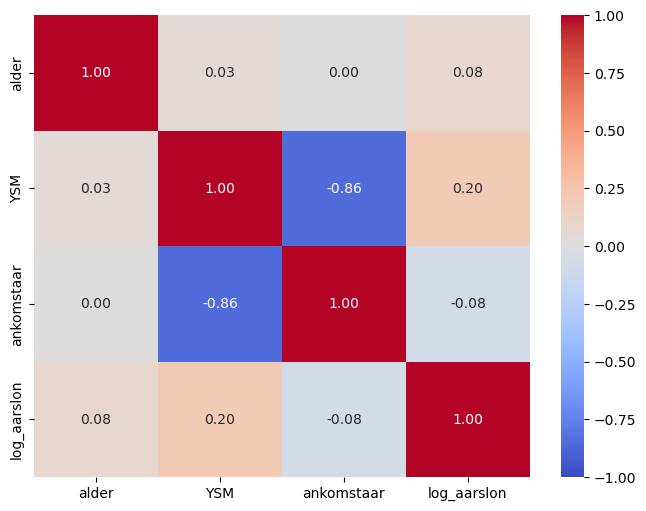

In [25]:
# Vælg de relevante variabler
variabler = ['alder', 'YSM', 'ankomstaar', 'log_aarslon']
corr_matrix = df[variabler].corr()

# Udskriv matricen som tal
print(corr_matrix)

# (Valgfrit) Plot den som et flot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.show()

##### 3.a - Tabel 5

In [26]:
D_year = year_dummies.columns.tolist()
#Fjerner referance kategorien 2014
D_year.remove("kohorte14")
df['alder2'] = df.alder**2
df['YSM2'] = df['YSM']**2

result3a = smf.ols('log_aarslon ~ alder + alder2 + YSM + YSM2 + kohorte15 + kohorte16', data=df).fit()

print(result3a.summary())

                            OLS Regression Results                            
Dep. Variable:            log_aarslon   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     114.6
Date:                Thu, 08 Oct 2026   Prob (F-statistic):          1.48e-135
Time:                        17:52:03   Log-Likelihood:                -3961.5
No. Observations:                4800   AIC:                             7937.
Df Residuals:                    4793   BIC:                             7982.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.0633      0.128     62.821      0.0

#### 3.b - F-test

In [27]:
# i) 
df['kohorte_1516'] = df['kohorte15'] + 2*df['kohorte16']
result3b = smf.ols('log_aarslon ~ alder + YSM + kohorte_1516', data=df).fit()

RSSur = result3a.ssr
RSSr = result3b.ssr
# q = 3 restriktioner, 7 = antal parameter
q = 3
n = len(df)
k_ur = 7

F_stat = ((RSSr - RSSur)/q)  /  ((RSSur)/(n-k_ur))
p = 1 - stats.f.cdf(F_stat, q, n-k_ur)

print(f'{F_stat = :.4f}')
print(f'{p = :.4f}')

# ii)
df_m=df[df['mand'] == 1]
df_k = df[df['mand'] == 0]

resultm = smf.ols('log_aarslon ~ alder + alder2 + YSM + YSM2 + kohorte15 + kohorte16', data=df_m).fit()
resultk = smf.ols('log_aarslon ~ alder + alder2 + YSM + YSM2 + kohorte15 + kohorte16', data=df_k).fit()
RSSm = resultm.ssr
RSSk = resultk.ssr

F_chow = ((RSSur -(RSSm + RSSk))/ k_ur) / ((RSSm + RSSk)/(n-2*k_ur))


p2 = 1 - stats.f.cdf(F_chow, k_ur, n - 2 * k_ur)
print(f'{F_chow = :.4f}')
print(f'{p2 = :.4f}')



F_stat = 96.3058
p = 0.0000
F_chow = 321.4585
p2 = 0.0000


##### 3.c - Breusch-Pagan test

In [28]:
df = df[df['mand'] == 1].copy()

result3c = smf.ols('log_aarslon ~ alder + alder2 + YSM + YSM2 + kohorte15 + kohorte16', data=df).fit()

df['uhat'] = result3c.resid
df['uhat2'] = df['uhat']**2

k = 6
n = len(df_m)
resultBP = smf.ols('uhat2 ~ alder + alder2 + YSM + YSM2 + kohorte15 + kohorte16', data=df).fit()
R2 = resultBP.rsquared

BP_test = (R2/k) / ((1-R2) /(n - k - 1)) 

pBP = 1 - stats.f.cdf(BP_test, k, n - k)
print(f'{BP_test = :.4f}')
print(f'{pBP = :.4f}')

LM_BP = n * R2
crit = stats.chi2.ppf(0.95, 6)

print(f"{LM_BP = :.4}")
print(f"critical value (LM) = {crit:.4}")

#BLIVER IKKE BRUGT SOM FIGUR, men aflæser t-værdier
print(resultBP.summary())

BP_test = 100.0099
pBP = 0.0000
LM_BP = 519.2
critical value (LM) = 12.59
                            OLS Regression Results                            
Dep. Variable:                  uhat2   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     100.0
Date:                Thu, 08 Oct 2026   Prob (F-statistic):          3.47e-117
Time:                        17:52:03   Log-Likelihood:                -1359.8
No. Observations:                3810   AIC:                             2734.
Df Residuals:                    3803   BIC:                             2777.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

##### 5.a  - Tabel 6

In [29]:
def simulate(n):
	## Step 1. Definer parameterværdier
	n 
	beta0 = 2
	beta1 = 3
	beta2 = -1
	beta3 = -1 

	# Step 2. Simular data, x bliver trukket fra N(1,4), derfor se(x) = 2
	x1 = np.random.normal(loc=1, scale=2, size=n) # Trækker x1 fra normalfordeling
	x2 = np.random.normal(loc=1, scale=2, size=n) # Trækker x2 fra normalfordeling
	x3 = np.random.normal(loc=1, scale=2, size=n) # Trækker x3 fra normalfordeling
	epsilon  = np.random.normal(loc= 0, scale=1/2 *x1**2, size=n) # Trækker u fra uniformfordeling
	y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + epsilon
	data = pd.DataFrame({
        'y': y,
        'x1': x1,
        'x2': x2,
        'x3': x3
    })

	# normale standardfejl
	result_ols = smf.ols('y ~ x1 + x2 + x3', data=data).fit()

	beta1_ols= result_ols.params['x1']
	se_ols = result_ols.bse['x1']
	

	#Robuste standardfejl
	result_robust = smf.ols('y ~ x1 + x2 + x3', data=data).fit(cov_type='HC1')

	beta1_robust = result_robust.params['x1']
	se_robust = result_robust.bse['x1']

	#t_test
	t_ols = (beta1_ols - 3)/ se_ols
	t_robust = (beta1_robust - 3) / se_robust

	#afvis
	reject_ols = abs(t_ols) > 1.96
	reject_robust = abs(t_robust) > 1.96
	

	return (
        beta1_ols, se_ols, reject_ols, beta1_robust, se_robust, reject_robust)

In [30]:
def monte_carlo1000(reps):
    np.random.seed(67)

    results = []

    for r in range(reps):
        result = simulate(1000)
        results.append(result)

    results = pd.DataFrame(results, columns=[
        'beta1_ols',
        'se_ols',
        'reject_ols',
        'beta1_robust',
        'se_robust',
        'reject_robust'
    ])

    return results

def monte_carlo50(reps):
    np.random.seed(67)

    results = []

    for r in range(reps):
        result = simulate(50)
        results.append(result)

    results = pd.DataFrame(results, columns=[
        'beta1_ols',
        'se_ols',
        'reject_ols',
        'beta1_robust',
        'se_robust',
        'reject_robust'
    ])

    return results

In [31]:
result = monte_carlo1000(1000)
#Normal standardfejl
result['beta1_ols'].mean()
result['beta1_ols'].std()
result['se_ols'].mean()
result['reject_ols'].mean()

#robuste
result['beta1_robust'].mean()
result['beta1_robust'].std()
result['se_robust'].mean()
result['reject_robust'].mean()



np.float64(0.053)

In [32]:
table = pd.DataFrame({
    'OLS': [
        result['beta1_ols'].mean(),
        result['beta1_ols'].std(),
        result['se_ols'].mean(),
        result['reject_ols'].mean()
    ],
    'Robust SE': [
        result['beta1_robust'].mean(),
        result['beta1_robust'].std(),
        result['se_robust'].mean(),
        result['reject_robust'].mean()
    ]
}, index=[
    'Mean beta1',
    'SD beta1',
    'Mean SE beta1',
    'Rejection rate H0'
])

table

,OLS,Robust SE
Mean beta1,3.004046,3.004046
SD beta1,0.142101,0.142101
Mean SE beta1,0.067276,0.137596
Rejection rate H0,0.347000,0.053000


#### 5.b - Tabel 7

In [33]:
result1 = monte_carlo50(1000)
#Normal standardfejl
result1['beta1_ols'].mean()
result1['beta1_ols'].std()
result1['se_ols'].mean()
result1['reject_ols'].mean()

#robuste
result1['beta1_robust'].mean()
result1['beta1_robust'].std()
result1['se_robust'].mean()
result1['reject_robust'].mean()


table = pd.DataFrame({
    'OLS': [
        result1['beta1_ols'].mean(),
        result1['beta1_ols'].std(),
        result1['se_ols'].mean(),
        result1['reject_ols'].mean()
    ],
    'Robust SE': [
        result1['beta1_robust'].mean(),
        result1['beta1_robust'].std(),
        result1['se_robust'].mean(),
        result1['reject_robust'].mean()
    ]
}, index=[
    'Mean beta1',
    'SD beta1',
    'Mean SE beta1',
    'Rejection rate H0'
])

table

,OLS,Robust SE
Mean beta1,3.031098,3.031098
SD beta1,0.577893,0.577893
Mean SE beta1,0.285142,0.485946
Rejection rate H0,0.284000,0.085000


#### 5.c - Tabel 8

In [34]:
def simulate(n):
	## Step 1. Definer parameterværdier
	n 
	beta0 = 2
	beta1 = 3
	beta2 = -1
	beta3 = -1 

	# Step 2. Simular data, x bliver trukket fra N(1,4), derfor se(x) = 2
	x1 = np.random.normal(loc=1, scale=2, size=n) # Trækker x1 fra normalfordeling
	x2 = np.random.normal(loc=1, scale=2, size=n) # Trækker x2 fra normalfordeling
	x3 = np.random.normal(loc=1, scale=2, size=n) # Trækker x3 fra normalfordeling
	epsilon  = np.random.normal(loc= 0, scale=1/2 *x1**2, size=n) # Trækker u fra uniformfordeling
	y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + epsilon
	data = pd.DataFrame({
        'y': y,
        'x1': x1,
        'x2': x2,
        'x3': x3
    })
	weight = 4 / x1**4

	# WLS
	result_WLS = smf.wls('y ~ x1 + x2 + x3', data=data, weights = weight).fit()

	beta1_WLS= result_WLS.params['x1']
	se_WLS = result_WLS.bse['x1']
	

	#Robuste standardfejl
	result_robust = smf.ols('y ~ x1 + x2 + x3', data=data).fit(cov_type='HC1')

	beta1_robust = result_robust.params['x1']
	se_robust = result_robust.bse['x1']

	#t_test
	t_WLS = (beta1_WLS - 3)/ se_WLS
	t_robust = (beta1_robust - 3) / se_robust

	#afvis
	reject_WLS = abs(t_WLS) > 1.96
	reject_robust = abs(t_robust) > 1.96
	

	return (
        beta1_WLS, se_WLS, reject_WLS, beta1_robust, se_robust, reject_robust)

def monte_carlo1000(reps):
    np.random.seed(50)

    results = []

    for r in range(reps):
        result = simulate(1000)
        results.append(result)

    results = pd.DataFrame(results, columns=[
        'beta1_WLS',
        'se_WLS',
        'reject_WLS',
        'beta1_robust',
        'se_robust',
        'reject_robust'
    ])

    return results

def monte_carlo50(reps):
    np.random.seed(50)

    results = []

    for r in range(reps):
        result = simulate(50)
        results.append(result)

    results = pd.DataFrame(results, columns=[
        'beta1_WLS',
        'se_WLS',
        'reject_WLS',
        'beta1_robust',
        'se_robust',
        'reject_robust'
    ])

    return results

In [35]:
result = monte_carlo1000(1000)
#Normal standardfejl
result['beta1_WLS'].mean()
result['beta1_WLS'].std()
result['se_WLS'].mean()
result['reject_WLS'].mean()

#robuste
result['beta1_robust'].mean()
result['beta1_robust'].std()
result['se_robust'].mean()
result['reject_robust'].mean()

result1 = monte_carlo50(1000)
#Normal standardfejl
result1['beta1_WLS'].mean()
result1['beta1_WLS'].std()
result1['se_WLS'].mean()
result1['reject_WLS'].mean()

#robuste
result1['beta1_robust'].mean()
result1['beta1_robust'].std()
result1['se_robust'].mean()
result1['reject_robust'].mean()


table50 = pd.DataFrame({
    'WLS': [
        result1['beta1_WLS'].mean(),
        result1['beta1_WLS'].std(),
        result1['se_WLS'].mean(),
        result1['reject_WLS'].mean()
    ],
    'Robust SE': [
        result1['beta1_robust'].mean(),
        result1['beta1_robust'].std(),
        result1['se_robust'].mean(),
        result1['reject_robust'].mean()
    ]
}, index=[
    'Mean beta1',
    'SD beta1',
    'Mean SE beta1',
    'Rejection rate H0'
])
table1000 = pd.DataFrame({
    'WLS': [
        result['beta1_WLS'].mean(),
        result['beta1_WLS'].std(),
        result['se_WLS'].mean(),
        result['reject_WLS'].mean()
    ],
    'Robust SE': [
        result['beta1_robust'].mean(),
        result['beta1_robust'].std(),
        result['se_robust'].mean(),
        result['reject_robust'].mean()
    ]
}, index=[
    'Mean beta1',
    'SD beta1',
    'Mean SE beta1',
    'Rejection rate H0'
])

print(f'n = 50: {table50}')
print(f'n=1000: {table1000}')


n = 50:                         WLS  Robust SE
Mean beta1         2.999259   3.030404
SD beta1           0.055662   0.558698
Mean SE beta1      0.048894   0.484486
Rejection rate H0  0.067000   0.094000
n=1000:                         WLS  Robust SE
Mean beta1         2.999985   2.994841
SD beta1           0.002495   0.135743
Mean SE beta1      0.002336   0.137578
Rejection rate H0  0.058000   0.045000
